# Validation of the non-linear model for the velocity-divergence power spectrum

**Author: Francesca Lepori**

The model predicts the normalised velocity-divergence spectrum

$${P}(k, z) \;=\; \frac{P_{\theta\theta}(k, z)}{\left[\mathcal{H}(z)\, f(z)\right]^{2}},$$

which coincides with the linear matter power spectrum on large scales. A test cosmology
$(h,\ \omega_{\rm cdm})$ is mapped onto the fiducial flat-$\Lambda$CDM cosmology at fixed $\sigma_{12}$
(evolution mapping), and the resulting prediction is compared against gevolution measurements.

Two variants of the model are validated:

| model | fiducial non-linear shape |
|---|---|
| `Pk_ref_nl_mod` | phenomenological ratio `model_ratio_fid` applied to the CLASS linear spectrum |
| `Pk_ref_nl_fromsim` | interpolated directly from the fiducial simulations (`get_pktheta_nl_interpolator`) |

## 1. Configuration

Everything that a reader might want to change is collected here.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import velocity_model as vm
from velocity_model import (
    read_gevolution_outputs,
    compute_derivatives_h,
    build_deriv_interpolator,
    get_pktheta_interpolator,
    get_pktheta_nl_interpolator,
    Pk_ref_nl_mod,
    Pk_ref_nl_fromsim,
)

plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
# =====================================================================
# Cosmologies
# =====================================================================
# Shared parameters (identical in the fiducial and test cosmologies).
COSMO_COMMON = dict(
    omega_b = 0.022032,
    n_s     = 0.9619,
    k_pivot = 0.05,        # 1/Mpc
    T_cmb   = 2.7255,      # K
    N_ur    = 3.046,
    A_s     = 2.215e-9,    # held fixed under the evolution mapping
)

FID  = dict(h=0.67556, omega_cdm=0.12038, **COSMO_COMMON)   # fiducial / reference
TEST = dict(h=0.60000, omega_cdm=0.13000, **COSMO_COMMON)   # cosmology being validated

# =====================================================================
# Simulation data
# =====================================================================
SIM_FIDUCIAL = 'sim-data/Ngrid1024Lbox256/h-deriv/h_0.67556_As_2.215e-9/'
SIM_TEST     = 'sim-data/Ngrid1024Lbox256/test_zsamp_new'

# gevolution filename conventions: {tag} = 'pkNNN', {field} = theta|omega|delta
TEMPLATE_FIDUCIAL = 'lcdm_box128_{tag}_{field}.dat'   # = velocity_model default
TEMPLATE_TEST     = 'lcdm_{tag}_{field}.dat'

# Snapshot tag -> redshift for the test-cosmology run (these are the z* obtained
# by matching sigma_12 to the fiducial snapshots).
SNAPSHOTS_TEST = {
    "pk000": 2.1170, "pk001": 2.0150, "pk002": 1.9133, "pk003": 1.8117,
    "pk004": 1.7102, "pk005": 1.6090, "pk006": 1.5080, "pk007": 1.4073,
    "pk008": 1.3069, "pk009": 1.2069, "pk010": 1.1073, "pk011": 1.0082,
    "pk012": 0.9097, "pk013": 0.8119, "pk014": 0.7149, "pk015": 0.6189,
    "pk016": 0.5241, "pk017": 0.4307, "pk018": 0.3390, "pk019": 0.2492,
    "pk020": 0.1619,
}

# Redshifts shown in the final figure (one panel each), low z first.
Z_PANELS = [0.1619, 0.5241, 1.0082, 2.0150]

# =====================================================================
# Model settings
# =====================================================================
# Out-of-range treatment of the fiducial non-linear measurement:
#   'extend' -> converge to linear theory below k_min, fitted power law above k_max
#   'strict' -> NaN (and a printed error) outside [k_min, k_max]
NL_MODE   = 'extend'
KMAX_NL   = vm.K_MAX_VALID      # 1.0 /Mpc, rough edge of the reliable sim range

USE_DERIV    = True             # include the dP/dh correction
INCLUDE_VORT = False            # add the vorticity contribution
KMAX_COMPARE = 1.0              # residuals are only shown for k <= this (1/Mpc)

# =====================================================================
# Plot style (shared with the other figures of the paper)
# =====================================================================
N_COLORS    = 7
base_colors = [
    '#0072B2',  # blue
    '#D55E00',  # vermilion
    '#009E73',  # green
    '#CC79A7',  # purple
    '#E69F00',  # orange
    '#56B4E9',  # light blue
    '#666666', #grey
]

base_colors = np.array(base_colors[:N_COLORS])

C_SIM = 'k'

FS_LABEL, FS_TICK, FS_LEGEND = 16, 12, 11
XLIM   = (0.02, 1.0)            # 1/Mpc
YLIM_P = (0.5e1, 1e5)
YLIM_R = (-2.8, 2.8)                # per cent
SHOW_ONE_PERCENT = True
SAVE_FIG = 'figures/pktheta_validation_4panel.pdf'

## 2. Simulation data

Load the test-cosmology snapshots, normalise them by $[\mathcal{H}(z) f(z)]^2$ and attach the Gaussian mode-counting error $\sigma_P = \sqrt{2/N_k}\,P$.

In [3]:
def class_params(cosmo, z_pk, **extra):
    """CLASS parameter dict for one of the cosmology dicts defined above."""
    params = dict(cosmo)
    params.update({
        'output': 'mPk, dTk, vTk',
        'lensing': 'no',
        'z_pk': ','.join(f'{z:.6f}' for z in z_pk),
        'P_k_max_h/Mpc': 300.0,
    })
    params.update(extra)
    return params


def load_sim_spectra(path, cosmo, snapshots, template, z_list):
    """Read gevolution outputs and return the normalised P_theta at each z in z_list.

    Returns {z: {'k', 'P', 'sigma', 'P_lin'}} with k in 1/Mpc and
    P = P_theta_sim / (Hconf * f)^2 / h^3 in Mpc^3 (same units as the model).
    """
    results = read_gevolution_outputs(path, cosmo['h'], redshifts=snapshots,
                                      filename_template=template)

    missing = [z for z in z_list if z not in results]
    if missing:
        raise ValueError(f"redshifts {missing} are not in the snapshot set "
                         f"{sorted(results)}")

    # one CLASS run: background normalisation + linear reference spectrum
    z_pk = sorted(set(list(z_list) + [0.0, 3.0]))
    cosmo_class = Class()
    cosmo_class.set(class_params(cosmo, z_pk))
    cosmo_class.compute()

    out = {}
    for z in z_list:
        h = cosmo['h']
        Hconf = cosmo_class.Hubble(z) / (1.0 + z) / h
        f_growth = cosmo_class.scale_independent_growth_factor_f(z)

        k = results[z]['k_theta'] * h                       # h/Mpc -> 1/Mpc
        P = results[z]['Pk_theta'] / (Hconf * f_growth) ** 2 / h ** 3
        sigma = np.sqrt(2.0 / results[z]['Nk_theta']) * P

        out[z] = {
            'k': k,
            'P': P,
            'sigma': sigma,
            'P_lin': np.array([cosmo_class.pk_lin(kk, z) for kk in k]),
        }

    cosmo_class.struct_cleanup()
    cosmo_class.empty()
    return out


sim = load_sim_spectra(SIM_TEST, TEST, SNAPSHOTS_TEST, TEMPLATE_TEST, Z_PANELS)

for z in Z_PANELS:
    k = sim[z]['k']
    print(f"z = {z:.4f}: {k.size:3d} bins, k in [{k.min():.4g}, {k.max():.4g}] 1/Mpc")

z = 0.1619: 1023 bins, k in [0.02116, 14.69] 1/Mpc
z = 0.5241: 1023 bins, k in [0.02116, 14.69] 1/Mpc
z = 1.0082: 1023 bins, k in [0.02116, 14.69] 1/Mpc
z = 2.0150: 1023 bins, k in [0.02116, 14.69] 1/Mpc


## 3. Interpolators and derivatives

Built once and reused at every redshift. The linear interpolators are evaluated at the mapped redshift $\tilde z$, which can fall slightly outside the tabulated range (including $\tilde z < 0$ for this test cosmology) — the interpolator extrapolates linearly in $z$ there.

In [4]:
Z_INTERP = np.linspace(0.0, 2.5, 50)

# --- linear spectra: fiducial, and fiducial-with-test-omega_cdm ---
params_fid       = class_params(FID, Z_INTERP)
params_omega_cdm = class_params({**FID, 'omega_cdm': TEST['omega_cdm']}, Z_INTERP)

pktheta_fid_interp       = get_pktheta_interpolator(params_fid,       z_vals=Z_INTERP)
pktheta_omega_cdm_interp = get_pktheta_interpolator(params_omega_cdm, z_vals=Z_INTERP)

# --- non-linear fiducial spectrum, measured from the fiducial simulations ---
pktheta_fid_nl_interp = get_pktheta_nl_interpolator(
    base_fiducial=SIM_FIDUCIAL,
    h=FID['h'],
    A_s_ref=FID['A_s'],
    mode=NL_MODE,
    kmax=KMAX_NL,
    pktheta_lin_interp=pktheta_fid_interp,   # needed by mode='extend'
)

[get_pktheta_nl_interpolator] mode='extend', 69/1023 sim nodes kept, valid range [0.02116, 0.9981] 1/Mpc; linear blend on [0.007053, 0.02116], tail slope n_eff in [-3.11, -2.30] fitted on [0.3327, 0.9981]
WARNING [get_pktheta_nl_interpolator]: sim and linear spectra differ by up to 18.5% at the top of the blend window (k = 0.02116 1/Mpc), so the low-k blend will show a kink. Lower k_blend_hi/k_blend_lo, or check the normalisation of the fiducial run.


In [5]:
# --- dP_theta/dh at fixed sigma_12 (expensive: reads all h-derivative runs) ---
start = time.time()
derivs_h = compute_derivatives_h()
deriv_interp, sigma_grid, logk_grid = build_deriv_interpolator(derivs_h)
deriv_arg = (deriv_interp, sigma_grid, logk_grid)   
print(f"derivatives + interpolator: {time.time() - start:.1f} s")

derivatives + interpolator: 238.2 s


## 4. Model evaluation

One function, called once per redshift. Both model variants are evaluated directly on the simulation $k$-grid, so the residuals need no further interpolation.

In [6]:
def evaluate_models(z, k=None):
    """Evaluate both non-linear model variants (and linear theory) at redshift z.

    Returns a dict with the model curves on the grid k (default: the simulation
    k-grid at that z) plus the residuals with respect to the simulation, masked
    to k <= KMAX_COMPARE.
    """
    d = sim[z]
    k = d['k'] if k is None else np.atleast_1d(k)

    common = dict(
        h=TEST['h'], omega_cdm=TEST['omega_cdm'],
        pktheta_fid_interp=pktheta_fid_interp,
        pktheta_omega_cdm_interp=pktheta_omega_cdm_interp,
        A_s_ref=FID['A_s'], omega_cdm_ref=FID['omega_cdm'], h_ref=FID['h'],
        include_vort=INCLUDE_VORT, deriv=USE_DERIV, deriv_interp=deriv_arg,
    )

    P_nl_lin = Pk_ref_nl_mod(k, z, **common)
    P_nl_sim = Pk_ref_nl_fromsim(k, z, pktheta_fid_nl_interp=pktheta_fid_nl_interp,
                                 **common)
    if INCLUDE_VORT:                      # the models return (P, P_vort) in that case
        P_nl_lin, P_nl_sim = P_nl_lin[0], P_nl_sim[0]

    mask = k <= KMAX_COMPARE
    return {
        'z': z,
        'k': k,
        'P_lin': d['P_lin'],
        'P_nl_lin': np.asarray(P_nl_lin).ravel(),
        'P_nl_sim': np.asarray(P_nl_sim).ravel(),
        'k_sim': d['k'], 'P_sim': d['P'], 'sigma_sim': d['sigma'],
        'mask': mask,
        'res_nl_lin': (np.asarray(P_nl_lin).ravel()[mask] - d['P'][mask]) / d['P'][mask],
        'res_nl_sim': (np.asarray(P_nl_sim).ravel()[mask] - d['P'][mask]) / d['P'][mask],
    }


start = time.time()
models = {z: evaluate_models(z) for z in Z_PANELS}
print(f"model evaluation at {len(Z_PANELS)} redshifts: {time.time() - start:.1f} s")

# quick numerical summary over the comparison range
print(f"\n{'z':>8} {'max |res| from linear':>24} {'max |res| from sim':>22}")
for z, m in models.items():
    print(f"{z:8.4f} {100*np.nanmax(np.abs(m['res_nl_lin'])):23.2f}% "
          f"{100*np.nanmax(np.abs(m['res_nl_sim'])):21.2f}%")

model evaluation at 4 redshifts: 36.8 s

       z    max |res| from linear     max |res| from sim
  0.1619                   18.80%                  2.58%
  0.5241                   21.47%                  1.03%
  1.0082                   18.72%                  0.93%
  2.0150                   17.15%                  0.74%


## 5. Validation figure

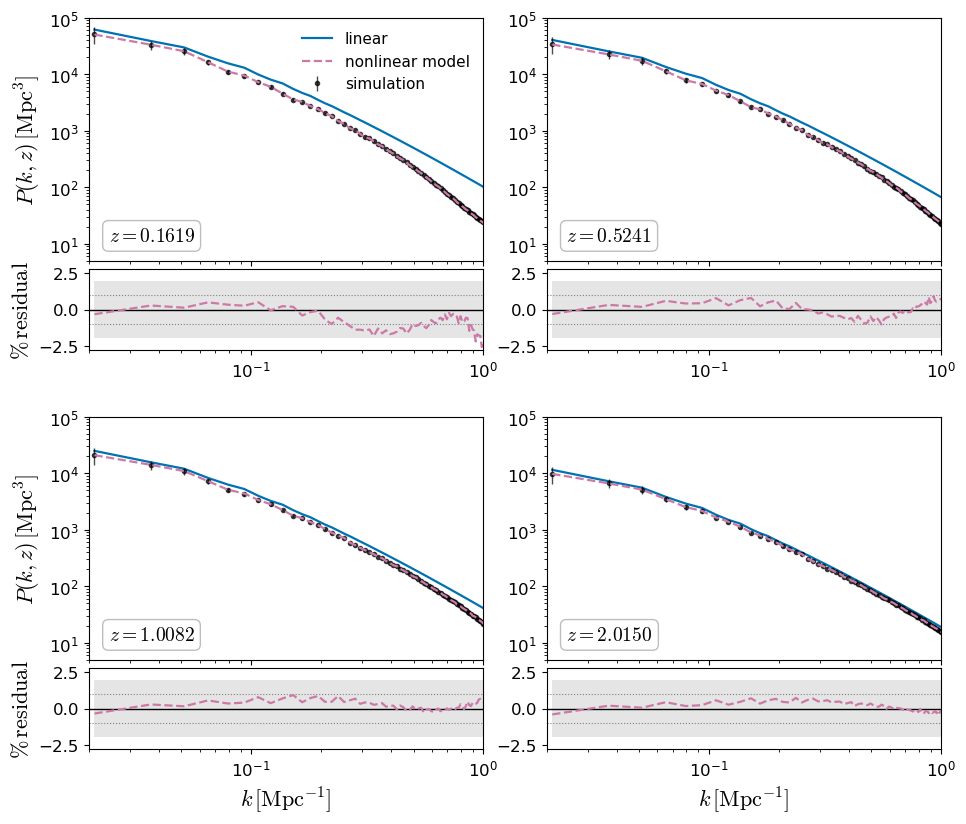

In [7]:
def plot_panel(ax_top, ax_res, m, show_legend=False, show_ylabel=False, show_xlabel=False):
    """One redshift: spectra on ax_top, per-cent residuals on ax_res."""
    k, ks = m['k'], m['k_sim']

    # --- spectra ---
    ax_top.plot(k, m['P_lin'], color=base_colors[0], lw=1.6, zorder=1, label='linear')
    ax_top.errorbar(ks, m['P_sim'], yerr=m['sigma_sim'], fmt='o', color=C_SIM,
                markersize=3, alpha=0.7, lw=1, zorder=2, label='simulation')
    ax_top.plot(k, m['P_nl_sim'], color=base_colors[3], lw=1.6, ls='--', zorder=3,
                label='nonlinear model')

    ax_top.set_xscale('log'); ax_top.set_yscale('log')
    ax_top.set_xlim(*XLIM); ax_top.set_ylim(*YLIM_P)
    #ax_top.grid(True, which='both', ls=':', alpha=0.5)
    ax_top.tick_params(labelsize=FS_TICK, labelbottom=False)
    ax_top.text(0.05, 0.08, rf'$z = {m["z"]:.4f}$', transform=ax_top.transAxes,
                fontsize=FS_LABEL - 2,
                bbox=dict(fc='white', ec='0.7', alpha=0.85, boxstyle='round,pad=0.3'))
    if show_ylabel:
        ax_top.set_ylabel(r'$P(k, z)\,[\mathrm{Mpc}^{3}]$',
                          fontsize=FS_LABEL)
    if show_legend:
        ax_top.legend(fontsize=FS_LEGEND, loc='upper right', frameon = False)

    # --- residuals ---
    kc, s = ks[m['mask']], m['sigma_sim'][m['mask']]
    P = m['P_sim'][m['mask']]

    ax_res.fill_between(kc, -2 , 2, color='gray', alpha=0.2, lw=0)

    if SHOW_ONE_PERCENT:
        for y in (-1.0, 1.0):
            ax_res.axhline(y, color='0.5', ls=':', lw=0.8)
    ax_res.axhline(0.0, color='k', lw=1.0)
    ax_res.plot(kc, 100 * m['res_nl_sim'], color=base_colors[3], lw=1.6, ls='--')

    ax_res.set_xscale('log')
    ax_res.set_xlim(*XLIM); ax_res.set_ylim(*YLIM_R)
    ax_res.tick_params(labelsize=FS_TICK)
    if show_ylabel:
        ax_res.set_ylabel(r'$\%\,\mathrm{residual}$', fontsize=FS_LABEL)
    if show_xlabel:
        ax_res.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$', fontsize=FS_LABEL)


fig = plt.figure(figsize=(11, 9.5))
outer = fig.add_gridspec(2, 2, hspace=0.20, wspace=0.16)

for i, z in enumerate(sorted(Z_PANELS)):
    row, col = i // 2, i % 2
    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_top = fig.add_subplot(inner[0])
    ax_res = fig.add_subplot(inner[1], sharex=ax_top)
    plot_panel(ax_top, ax_res, models[z],
               show_legend=(i == 0), show_ylabel=(col == 0), show_xlabel=(row == 1))

if SAVE_FIG:
    fig.savefig(SAVE_FIG, bbox_inches='tight', dpi=300)
plt.show()

## 6. The two out-of-range treatments

`get_pktheta_nl_interpolator` offers two ways of handling wavenumbers outside the range where the fiducial measurement is reliable, $k_{\rm min} \le k \le k_{\rm max} = 1\,\mathrm{Mpc}^{-1}$:

- **`mode='strict'`** returns `NaN` outside the range and prints an explicit error, so nothing extrapolated can leak into a figure or a fit;
- **`mode='extend'`** converges smoothly onto linear theory below $k_{\rm min}$ and continues with a power law $P \propto k^{n_{\rm eff}(z)}$ above $k_{\rm max}$, with $n_{\rm eff}$ fitted on the reliable sub-range only.

The cell below shows that the two agree exactly inside the validity range, and what each does outside it.

[get_pktheta_nl_interpolator] mode='strict', 69/1023 sim nodes kept, valid range [0.02116, 0.9981] 1/Mpc
[get_pktheta_nl_interpolator] mode='extend', 69/1023 sim nodes kept, valid range [0.02116, 0.9981] 1/Mpc; linear blend on [0.007053, 0.02116], tail slope n_eff in [-3.11, -2.30] fitted on [0.3327, 0.9981]
WARNING [get_pktheta_nl_interpolator]: sim and linear spectra differ by up to 18.5% at the top of the blend window (k = 0.02116 1/Mpc), so the low-k blend will show a kink. Lower k_blend_hi/k_blend_lo, or check the normalisation of the fiducial run.
ERROR [get_pktheta_nl_interpolator, mode='strict']: 165/300 requested k values lie outside the validity range [0.02116, 0.9981] 1/Mpc (offending k in [0.001, 5.012] 1/Mpc); these are returned as NaN. Restrict the k array, or use mode='extend' for a controlled continuation.
max |extend/strict - 1| inside the validity range: 0.00e+00
fitted tail slope n_eff at z=0.0: -3.105


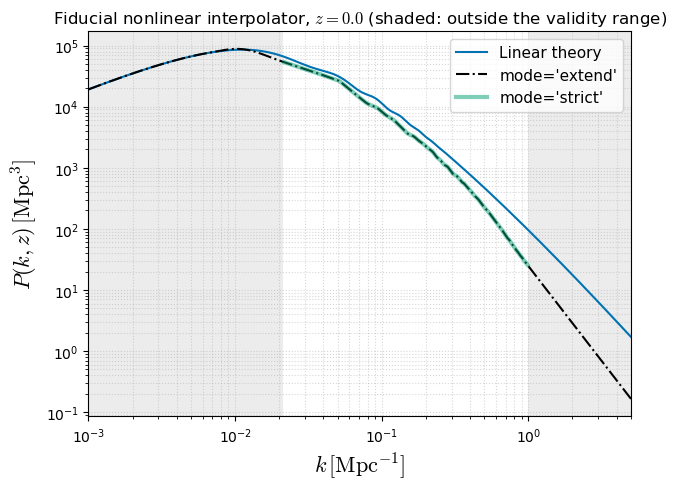

In [8]:
nl_strict = get_pktheta_nl_interpolator(
    base_fiducial=SIM_FIDUCIAL, h=FID['h'], A_s_ref=FID['A_s'],
    mode='strict', kmax=KMAX_NL,
)
nl_extend = get_pktheta_nl_interpolator(
    base_fiducial=SIM_FIDUCIAL, h=FID['h'], A_s_ref=FID['A_s'],
    mode='extend', kmax=KMAX_NL, pktheta_lin_interp=pktheta_fid_interp,
)

k_test = np.logspace(-3, 0.7, 300)
z_test = 0.0
pts = np.column_stack([k_test, np.full_like(k_test, z_test)])

P_strict = nl_strict(pts)
P_extend = nl_extend(pts)
P_lin    = pktheta_fid_interp(pts)

inside = np.isfinite(P_strict)
print(f"max |extend/strict - 1| inside the validity range: "
      f"{np.nanmax(np.abs(P_extend[inside] / P_strict[inside] - 1.0)):.2e}")
print(f"fitted tail slope n_eff at z={z_test}: "
      f"{np.interp(z_test, nl_extend.z_grid, nl_extend.n_eff):.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_test, P_lin, color=base_colors[0], lw=1.5, label='Linear theory')
ax.plot(k_test, P_extend, color=C_SIM, lw=1.5, ls='-.', label="mode='extend'")
ax.plot(k_test, P_strict, color=base_colors[2], lw=3.0, alpha=0.5, label="mode='strict'")
ax.axvspan(XLIM[0] * 1e-2, nl_extend.k_min, color='gray', alpha=0.15, lw=0)
ax.axvspan(nl_extend.k_max, k_test.max(), color='gray', alpha=0.15, lw=0)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(k_test.min(), k_test.max())
ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$', fontsize=FS_LABEL)
ax.set_ylabel(r'$P(k, z)\,[\mathrm{Mpc}^{3}]$', fontsize=FS_LABEL)
ax.set_title(rf'Fiducial nonlinear interpolator, $z={z_test}$ '
             '(shaded: outside the validity range)', fontsize=FS_LEGEND + 1)
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=FS_LEGEND)
plt.show()

## 7. The vorticity contribution (fiducial cosmology)

The model can add a vorticity term to the velocity-divergence spectrum,

$$\tilde P_{\rm tot}(k, z) \;=\; \tilde P_{\theta\theta}(k, z) \;+\; \tilde P_{\omega}(k, z),$$

with $\tilde P_{\omega}$ given by the phenomenological `Pk_vorticity` fit. Here everything is
evaluated in the **fiducial** cosmology ($h = h_{\rm fid}$, $\omega_{\rm cdm} = \omega_{\rm cdm,fid}$,
no $\partial P/\partial h$ correction), so the evolution mapping is the identity
($\tilde z = z$, `ratio_nl` $=1$) and the figure isolates the size of the vorticity term itself.

Each panel shows linear theory, the non-linear model with and without vorticity, and the
vorticity term alone; the lower sub-panel gives the vorticity contribution in per cent,
$100\,\tilde P_{\omega} / \tilde P_{\theta\theta}$, on a logarithmic scale (the term is steeply
suppressed towards high redshift, $\tilde P_\omega \propto D^{7}$).

> **Note.** `_finalize_pk_theta_nl` calls `Pk_vorticity(k, z, D_growth_test_spline(z), h)`, but the
> fourth positional argument of `Pk_vorticity` is the small-scale slope `a`, not `h` — that branch
> therefore silently replaces $a = 2.5$ by $a = h$. The cell below calls `Pk_vorticity` directly
> with keyword arguments so the intended defaults are used.


In [15]:
# =====================================================================
# Vorticity figure: configuration
# =====================================================================
Z_PANELS_VORT = [0.0, 0.5, 1.0, 2.0]      # fiducial snapshot redshifts, low z first
K_VORT = np.logspace(np.log10(XLIM[0]), np.log10(XLIM[1]), 400)   # 1/Mpc

YLIM_P_VORT    = (1e-3, 1e5)     # Mpc^3 -- extended downwards to fit P_omega
YLIM_FRAC_VORT = (1.0e-3, 50.0)     # per cent
SAVE_FIG_VORT  = 'figures/pktheta_vorticity_4panel.pdf'

# Linear growth factor D(z)/D(0) of the fiducial cosmology (one CLASS run).
_, D_fid = vm.compute_sigma12(FID['A_s'], FID['h'], FID['omega_cdm'],
                              R=12.0, z=0.0, give_growth=True)


def evaluate_vorticity(z, k=K_VORT):
    """Fiducial-cosmology model at redshift z, with and without vorticity.

    Returns {'z', 'k', 'P_lin', 'P_theta', 'P_vort', 'P_tot', 'frac_vort'} with
    all spectra in Mpc^3 and frac_vort = 100 * P_omega / P_theta in per cent.
    """
    pts = np.column_stack([k, np.full_like(k, z)])
    P_lin = np.asarray(pktheta_fid_interp(pts)).ravel()

    # Fiducial cosmology: pass the *fiducial* linear interpolator twice, so that
    # ratio_lin = 1 (no omega_cdm mapping), and switch off the dP/dh correction.
    P_theta = np.asarray(Pk_ref_nl_fromsim(
        k, z,
        h=FID['h'], omega_cdm=FID['omega_cdm'],
        pktheta_fid_interp=pktheta_fid_interp,
        pktheta_omega_cdm_interp=pktheta_fid_interp,
        pktheta_fid_nl_interp=pktheta_fid_nl_interp,
        A_s_ref=FID['A_s'], omega_cdm_ref=FID['omega_cdm'], h_ref=FID['h'],
        include_vort=False, deriv=False,
    )).ravel()

    # Vorticity term, called with keywords (see the note above).
    P_vort = np.asarray(vm.Pk_vorticity(k, z, D1=float(D_fid(z)))).ravel()

    return {
        'z': z, 'k': k,
        'P_lin': P_lin,
        'P_theta': P_theta,
        'P_vort': P_vort,
        'P_tot': P_theta + P_vort,
        'frac_vort': 100.0 * P_vort / (P_theta + P_vort),
    }


start = time.time()
models_vort = {z: evaluate_vorticity(z) for z in Z_PANELS_VORT}
print(f"vorticity model at {len(Z_PANELS_VORT)} redshifts: {time.time() - start:.1f} s")

print(f"\n{'z':>8} {'D(z)':>8} {'max % vorticity':>18} {'at k [1/Mpc]':>14}")
for z, m in models_vort.items():
    i = int(np.nanargmax(m['frac_vort']))
    print(f"{z:8.2f} {float(D_fid(z)):8.4f} {m['frac_vort'][i]:17.3f}% {m['k'][i]:14.3f}")

vorticity model at 4 redshifts: 14.4 s

       z     D(z)    max % vorticity   at k [1/Mpc]
    0.00   1.0000            38.944%          1.000
    0.50   0.7698             8.573%          1.000
    1.00   0.6078             1.350%          1.000
    2.00   0.4181             0.070%          1.000


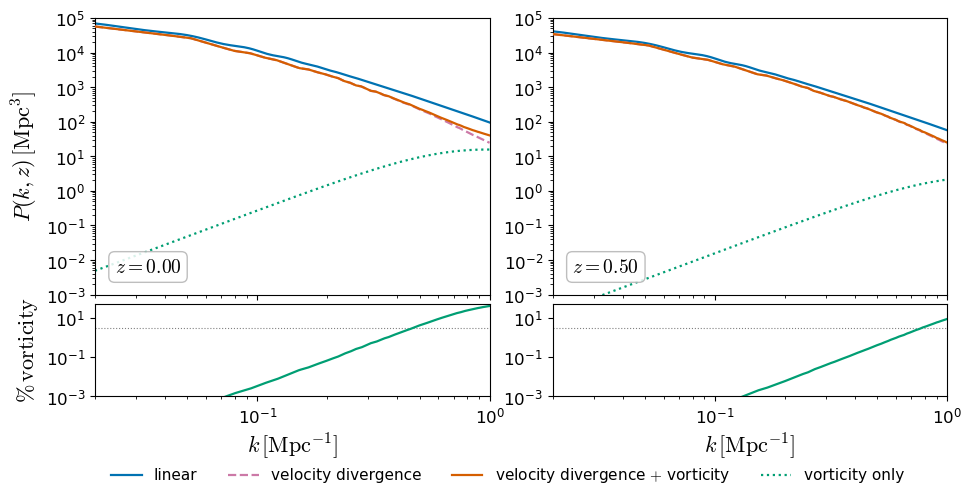

In [17]:
def plot_vort_panel(ax_top, ax_frac, m,
                    show_ylabel=False, show_xlabel=False):
    """One redshift: spectra on ax_top, per-cent vorticity contribution on ax_frac."""
    k = m['k']

    # --- spectra ---
    ax_top.plot(
        k, m['P_lin'],
        color=base_colors[0], lw=1.6, zorder=1,
        label='linear'
    )
    ax_top.plot(
        k, m['P_theta'],
        color=base_colors[3], lw=1.6, ls='--', zorder=3,
        label=r'velocity divergence'
    )
    ax_top.plot(
        k, m['P_tot'],
        color=base_colors[1], lw=1.6, zorder=4,
        label=r'velocity divergence $+$ vorticity'
    )
    ax_top.plot(
        k, m['P_vort'],
        color=base_colors[2], lw=1.6, ls=':', zorder=2,
        label=r'vorticity only'
    )

    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.set_xlim(*XLIM)
    ax_top.set_ylim(*YLIM_P_VORT)
    ax_top.tick_params(labelsize=FS_TICK, labelbottom=False)

    ax_top.text(
        0.05, 0.08,
        rf'$z = {m["z"]:.2f}$',
        transform=ax_top.transAxes,
        fontsize=FS_LABEL - 2,
        bbox=dict(
            fc='white',
            ec='0.7',
            alpha=0.85,
            boxstyle='round,pad=0.3'
        )
    )

    if show_ylabel:
        ax_top.set_ylabel(
            r'$P(k,z)\,[\mathrm{Mpc}^{3}]$',
            fontsize=FS_LABEL
        )

    # --- vorticity contribution ---
    if SHOW_ONE_PERCENT:
        ax_frac.axhline(
            3.0,
            color='0.5',
            ls=':',
            lw=0.8
        )

    ax_frac.plot(
        k, m['frac_vort'],
        color=base_colors[2],
        lw=1.6
    )

    ax_frac.set_xscale('log')
    ax_frac.set_yscale('log')
    ax_frac.set_xlim(*XLIM)
    ax_frac.set_ylim(*YLIM_FRAC_VORT)
    ax_frac.tick_params(labelsize=FS_TICK)

    if show_ylabel:
        ax_frac.set_ylabel(
            r'$\%\,\mathrm{vorticity}$',
            fontsize=FS_LABEL
        )

    if show_xlabel:
        ax_frac.set_xlabel(
            r'$k\,[\mathrm{Mpc}^{-1}]$',
            fontsize=FS_LABEL
        )


# Keep only z = 0 and z = 0.5
z_panels_to_plot = [
    z for z in sorted(Z_PANELS_VORT)
    if not np.isclose(z, 1.0) and not np.isclose(z, 2.0)
]

fig = plt.figure(figsize=(11, 5.4))

# Leave room at the bottom for the external legend
outer = fig.add_gridspec(
    1, 2,
    wspace=0.16
)

top_axes = []

for i, z in enumerate(z_panels_to_plot):
    inner = outer[0, i].subgridspec(
        2, 1,
        height_ratios=[3, 1],
        hspace=0.05
    )

    ax_top = fig.add_subplot(inner[0])
    ax_frac = fig.add_subplot(inner[1], sharex=ax_top)

    plot_vort_panel(
        ax_top,
        ax_frac,
        models_vort[z],
        show_ylabel=(i == 0),
        show_xlabel=True
    )

    top_axes.append(ax_top)


# Figure-level legend below both panels
handles, labels = top_axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    fontsize=FS_LEGEND,
    frameon=False
)

fig.subplots_adjust(bottom=0.18)

if SAVE_FIG_VORT:
    fig.savefig(
        SAVE_FIG_VORT,
        bbox_inches='tight',
        dpi=300
    )

plt.show()